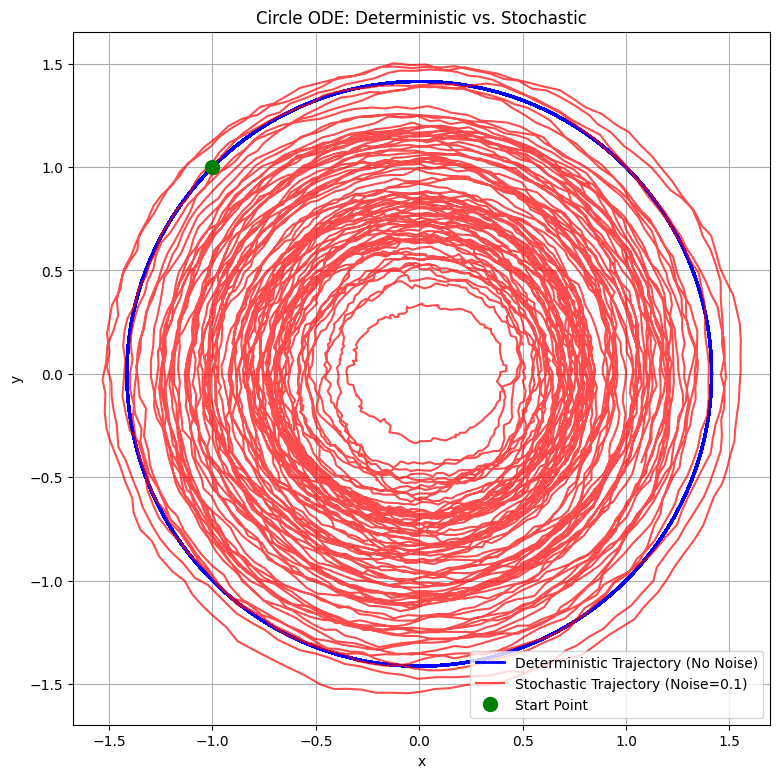

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --- ODE Class Definitions ---

class CircleODE(nn.Module):
    """Defines the ODE: dx/dt = omega*y, dy/dt = -omega*x."""
    def __init__(self):
        super(CircleODE, self).__init__()

    @staticmethod
    def forward(t, x, omega=1.0):
        # Input: t, x(batch,2), omega
        # Output: dx/dt(batch,2)
        rvals = torch.zeros_like(x)
        rvals[:, 0] = omega * x[:, 1]
        rvals[:, 1] = -omega * x[:, 0]
        return rvals

# --- RK4 Solver ---

def rk4(func, u, t, dt):
    """4th-order Runge-Kutta step."""
    k1 = func(t, u)
    k2 = func(t + dt/2, u + dt/2*k1)
    k3 = func(t + dt/2, u + dt/2*k2)
    k4 = func(t + dt, u + dt*k3)
    u_n = u + dt/6*(k1 + 2*k2 + 2*k3 + k4)
    return u_n

# --- Stochastic Simulation Function ---

def run_stochastic_simulation(ode, u0, dt, num_steps, noise_strength, **kwargs):
    """
    Runs a simulation with an RK4 step followed by an additive noise term.
    """
    func = lambda t, u: ode.forward(t, u, **kwargs)
    
    u = u0
    history = [u0]
    for i in range(num_steps):
        t = i * dt
        # Compute the deterministic step
        u_det = rk4(func, u.unsqueeze(0), t, dt).squeeze(0)
        
        # Generate and add the forward noise
        noise = noise_strength * torch.randn_like(u)
        
        u = u_det + noise
        history.append(u)
        
    return torch.stack(history).detach().numpy()


# --- Main Simulation and Plotting ---

# 1. Setup
circle_ode_instance = CircleODE()
u0 = torch.tensor([-1.0, 1.0])
dt = 0.05
num_steps = 10000 # More steps to see the diffusion effect
ode_params = {'omega': 1.0}

# 2. Run both deterministic and stochastic simulations
# Deterministic case
traj_det = run_stochastic_simulation(circle_ode_instance, u0, dt, num_steps, noise_strength=0.0, **ode_params)
# Stochastic case
traj_stoch = run_stochastic_simulation(circle_ode_instance, u0, dt, num_steps, noise_strength=0.01, **ode_params)

# 3. Plotting
plt.figure(figsize=(9, 9))
# Plot the deterministic (clean) trajectory
plt.plot(traj_det[:, 0], traj_det[:, 1], 'b-', label='Deterministic Trajectory (No Noise)', linewidth=2)
# Plot the stochastic (noisy) trajectory
plt.plot(traj_stoch[:, 0], traj_stoch[:, 1], 'r-', label='Stochastic Trajectory (Noise=0.1)', alpha=0.7)
plt.plot(u0[0], u0[1], 'go', markersize=10, label='Start Point')

plt.title("Circle ODE: Deterministic vs. Stochastic")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.axis('equal') # Ensure the circle is not distorted
plt.show()

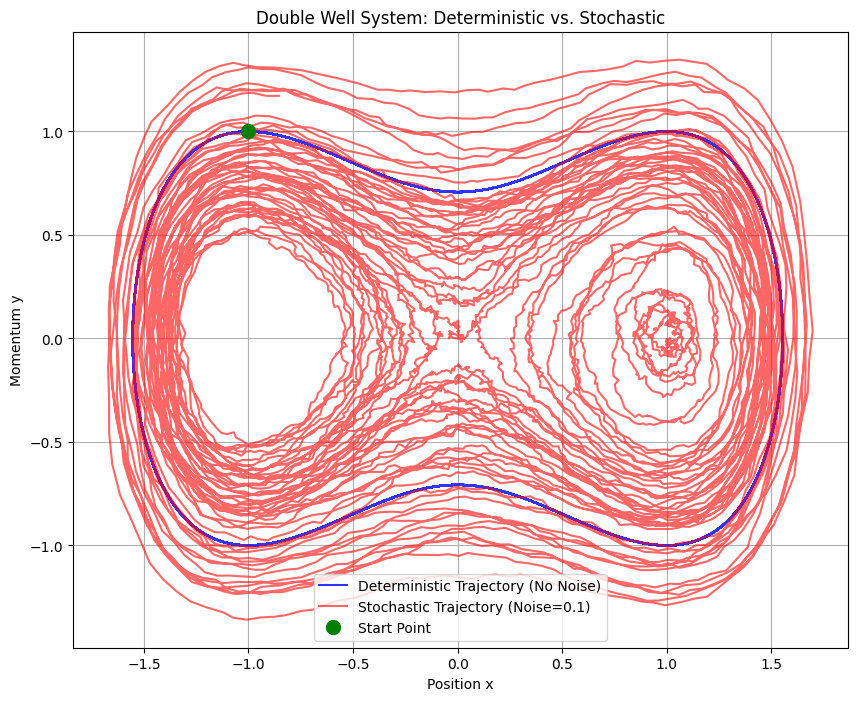

In [8]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --- ODE Class Definitions (no changes needed) ---

class DoubleWellODE(nn.Module):
    """Defines the ODE for a double-well potential: dx/dt = y, dy/dt = b*x - a*x^3."""
    def __init__(self):
        super(DoubleWellODE, self).__init__()

    @staticmethod
    def forward(t, x, a=1.0, b=1.0):
        # Input: t, x(batch,2), a, b
        # Output: dx/dt(batch,2)
        rvals = torch.zeros_like(x)
        rvals[:, 0] = x[:, 1]
        rvals[:, 1] = b * x[:, 0] - a * (x[:, 0]**3)
        return rvals

# --- RK4 Solver (no changes needed) ---

def rk4(func, u, t, dt):
    """4th-order Runge-Kutta step."""
    k1 = func(t, u)
    k2 = func(t + dt/2, u + dt/2*k1)
    k3 = func(t + dt/2, u + dt/2*k2)
    k4 = func(t + dt, u + dt*k3)
    u_n = u + dt/6*(k1 + 2*k2 + 2*k3 + k4)
    return u_n

# --- Stochastic Simulation Function ---

def run_stochastic_simulation(ode, u0, dt, num_steps, noise_strength, **kwargs):
    """
    Runs a simulation with an RK4 step followed by an additive noise term.
    """
    func = lambda t, u: ode.forward(t, u, **kwargs)
    
    u = u0
    history = [u0]
    for i in range(num_steps):
        t = i * dt
        # 1. Compute the deterministic step using RK4
        u_det = rk4(func, u.unsqueeze(0), t, dt).squeeze(0)
        
        # 2. Generate and add the forward noise
        # torch.randn_like(u) creates a tensor of random numbers from N(0, I)
        # with the same shape as u.
        noise = noise_strength * torch.randn_like(u)
        
        u = u_det + noise
        history.append(u)
        
    return torch.stack(history).detach().numpy()

# --- Main Simulation and Plotting ---

# 1. Setup
dw_ode_instance = DoubleWellODE()
u0 = torch.tensor([-1.0, 1.0])  # Start with a low-energy state
dt = 0.05
num_steps = 10000
ode_params = {'a': 1.0, 'b': 1.0}

# 2. Run both deterministic and stochastic simulations
# Deterministic case (no noise)
traj_det = run_stochastic_simulation(dw_ode_instance, u0, dt, num_steps, noise_strength=0.0, **ode_params)
# Stochastic case
traj_stoch = run_stochastic_simulation(dw_ode_instance, u0, dt, num_steps, noise_strength=0.01, **ode_params)


# 3. Plotting
plt.figure(figsize=(10, 8))
# Plot the deterministic (clean) trajectory
plt.plot(traj_det[:, 0], traj_det[:, 1], 'b-', label='Deterministic Trajectory (No Noise)', alpha=0.8)
# Plot the stochastic (noisy) trajectory
plt.plot(traj_stoch[:, 0], traj_stoch[:, 1], 'r-', label='Stochastic Trajectory (Noise=0.1)', alpha=0.6)
plt.plot(u0[0], u0[1], 'go', markersize=10, label='Start Point')

plt.title("Double Well System: Deterministic vs. Stochastic")
plt.xlabel("Position x")
plt.ylabel("Momentum y")
plt.grid(True)
plt.legend()
plt.show()